# Quantium Virtual Internship 

## Retail Strategy and Analytics: Data Preparation & Customer Analysis

**Author:** Your Name  
**Program:** Quantium Data Analytics - Forage  
**Objective:** Analyse transaction and customer data to understand chip purchasing behaviour and provide strategic recommendations to the Category Manager.
    
---

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import re 
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

In [3]:
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)   # Plot styling

In [ ]:
transaction_data = pd.read_excel('../Data/QVI_Transaction_Data.xlsx')
customer_data = pd.read_csv('../Data/QVI_Purchase_Behaviour.csv')

print(f'Transaction data shape : {transaction_data.shape}')
print(f'Customer data shape    : {customer_data.shape}')

Transaction data shape : (264836, 8)
Customer data shape    : (72637, 3)


### EDA EXPLORATORY DATA ANALYSIS - TRANSACTION DATA

In [5]:
# The overview

print('  THE DATA TYPES ')
print(transaction_data.dtypes)

print('\n=== FIRST 5 ROWS ===')

transaction_data.head()

  THE DATA TYPES 
DATE                int64
STORE_NBR           int64
LYLTY_CARD_NBR      int64
TXN_ID              int64
PROD_NBR            int64
PROD_NAME          object
PROD_QTY            int64
TOT_SALES         float64
dtype: object

=== FIRST 5 ROWS ===


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [6]:
print('=== SUMMARY STATISTICS ===')
transaction_data.describe()

=== SUMMARY STATISTICS ===


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,264836.000000,264836.00000,2.648360e+05,2.648360e+05,264836.000000,264836.000000,264836.000000
mean,43464.036260,135.08011,1.355495e+05,1.351583e+05,56.583157,1.907309,7.304200
std,105.389282,76.78418,8.057998e+04,7.813303e+04,32.826638,0.643654,3.083226
min,43282.000000,1.00000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.500000
25%,43373.000000,70.00000,7.002100e+04,6.760150e+04,28.000000,2.000000,5.400000
50%,43464.000000,130.00000,1.303575e+05,1.351375e+05,56.000000,2.000000,7.400000
75%,43555.000000,203.00000,2.030942e+05,2.027012e+05,85.000000,2.000000,9.200000
max,43646.000000,272.00000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000


#### 1.1 RECTIFYING DATE COLUMN

In [7]:
# Excel serial to Python date

transaction_data['DATE'] = pd.to_datetime(
    transaction_data['DATE'], unit='D', origin='1899-12-30'
).dt.date

transaction_data['DATE'] = pd.to_datetime(transaction_data['DATE'])

print('Date range:', transaction_data['DATE'].min(), '→', transaction_data['DATE'].max())
print('Date dtype:', transaction_data['DATE'].dtype)

Date range: 2018-07-01 00:00:00 → 2019-06-30 00:00:00
Date dtype: datetime64[ns]


#### 1.2  EXAMINE PROD_NAME AND REMOVING NON CHIP PRODUCTS

In [8]:
# Word frequency analysis to spot non-chip items

all_words = ' '.join(transaction_data['PROD_NAME'].unique())
words = re.findall(r'[A-Za-z]+', all_words)         
word_freq = Counter(w.upper() for w in words)

# Display top 30 most common words

word_df = pd.DataFrame(word_freq.most_common(30), columns=['Word', 'Count'])
print(word_df.to_string(index=False))

    Word  Count
       G    114
   CHIPS     21
  SMITHS     16
 CRINKLE     14
     CUT     14
  KETTLE     13
  CHEESE     12
    SALT     12
ORIGINAL     10
    CHIP      9
   SALSA      9
 DORITOS      9
 CHICKEN      8
   CREAM      8
    CORN      8
PRINGLES      8
     RRD      8
  CHILLI      7
      WW      7
    SOUR      6
     SEA      6
  THINLY      5
 VINEGAR      5
   THINS      5
  CRISPS      5
 NATURAL      4
   SWEET      4
  CHIVES      4
    LIME      4
     RED      4


In [9]:
# 'SALSA' products are NOT chips so we remove them

salsa_mask = transaction_data['PROD_NAME'].str.contains('salsa', case=False, na=False)
print(f'Salsa products found: {salsa_mask.sum()} rows — removing...')
transaction_data = transaction_data[~salsa_mask].copy()
print(f'Rows after removal: {len(transaction_data)}') 

Salsa products found: 18094 rows — removing...
Rows after removal: 246742


#### 1.3  NULL VALUES AND OUTLIERS

In [10]:
print('=== NULL COUNTS ===')
print(transaction_data.isnull().sum())
print('\n=== SUMMARY ===')
transaction_data.describe()

=== NULL COUNTS ===
DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0
dtype: int64

=== SUMMARY ===


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,246742,246742.000000,2.467420e+05,2.467420e+05,246742.000000,246742.000000,246742.000000
mean,2018-12-30 01:19:01.211467520,135.051098,1.355310e+05,1.351311e+05,56.351789,1.908062,7.321322
min,2018-07-01 00:00:00,1.000000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.700000
25%,2018-09-30 00:00:00,70.000000,7.001500e+04,6.756925e+04,26.000000,2.000000,5.800000
50%,2018-12-30 00:00:00,130.000000,1.303670e+05,1.351830e+05,53.000000,2.000000,7.400000
75%,2019-03-31 00:00:00,203.000000,2.030840e+05,2.026538e+05,87.000000,2.000000,8.800000
max,2019-06-30 00:00:00,272.000000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000
std,NaN,76.787096,8.071528e+04,7.814772e+04,33.695428,0.659831,3.077828


In [11]:
# PROD_QTY max is suspiciously high

outlier = transaction_data[transaction_data['PROD_QTY'] >= 200]
print('Outlier transactions (PROD_QTY >= 200):')
print(outlier)

Outlier transactions (PROD_QTY >= 200):
            DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR  \
69762 2018-08-19        226          226000  226201         4   
69763 2019-05-20        226          226000  226210         4   

                              PROD_NAME  PROD_QTY  TOT_SALES  
69762  Dorito Corn Chp     Supreme 380g       200      650.0  
69763  Dorito Corn Chp     Supreme 380g       200      650.0  


In [12]:

suspect_card = outlier['LYLTY_CARD_NBR'].values[0]
print(f'All transactions for loyalty card {suspect_card}:')
print(transaction_data[transaction_data['LYLTY_CARD_NBR'] == suspect_card])

All transactions for loyalty card 226000:
            DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR  \
69762 2018-08-19        226          226000  226201         4   
69763 2019-05-20        226          226000  226210         4   

                              PROD_NAME  PROD_QTY  TOT_SALES  
69762  Dorito Corn Chp     Supreme 380g       200      650.0  
69763  Dorito Corn Chp     Supreme 380g       200      650.0  


In [13]:

transaction_data = transaction_data[
    transaction_data['LYLTY_CARD_NBR'] != suspect_card
].copy()

print(f'Rows after removing outlier customer: {len(transaction_data)}')
print('Max PROD_QTY now:', transaction_data['PROD_QTY'].max())

Rows after removing outlier customer: 246740
Max PROD_QTY now: 5


#### 1.4 TRANSACTION COUNT OVER TIME - SPOT MISSING DATES

In [14]:
# Count transactions per day

txn_by_day = transaction_data.groupby('DATE').size().reset_index(name='TXN_COUNT')



full_dates = pd.DataFrame(
    {'DATE': pd.date_range(start='2018-07-01', end='2019-06-30', freq='D')}
)
txn_by_day = full_dates.merge(txn_by_day, on='DATE', how='left').fillna(0)

print(f'Days with data  : {(txn_by_day["TXN_COUNT"] > 0).sum()}')
print(f'Days with 0 txn : {(txn_by_day["TXN_COUNT"] == 0).sum()}')
print('Missing dates:')
print(txn_by_day[txn_by_day['TXN_COUNT'] == 0]['DATE'].values)

Days with data  : 364
Days with 0 txn : 1
Missing dates:
['2018-12-25T00:00:00.000000000']


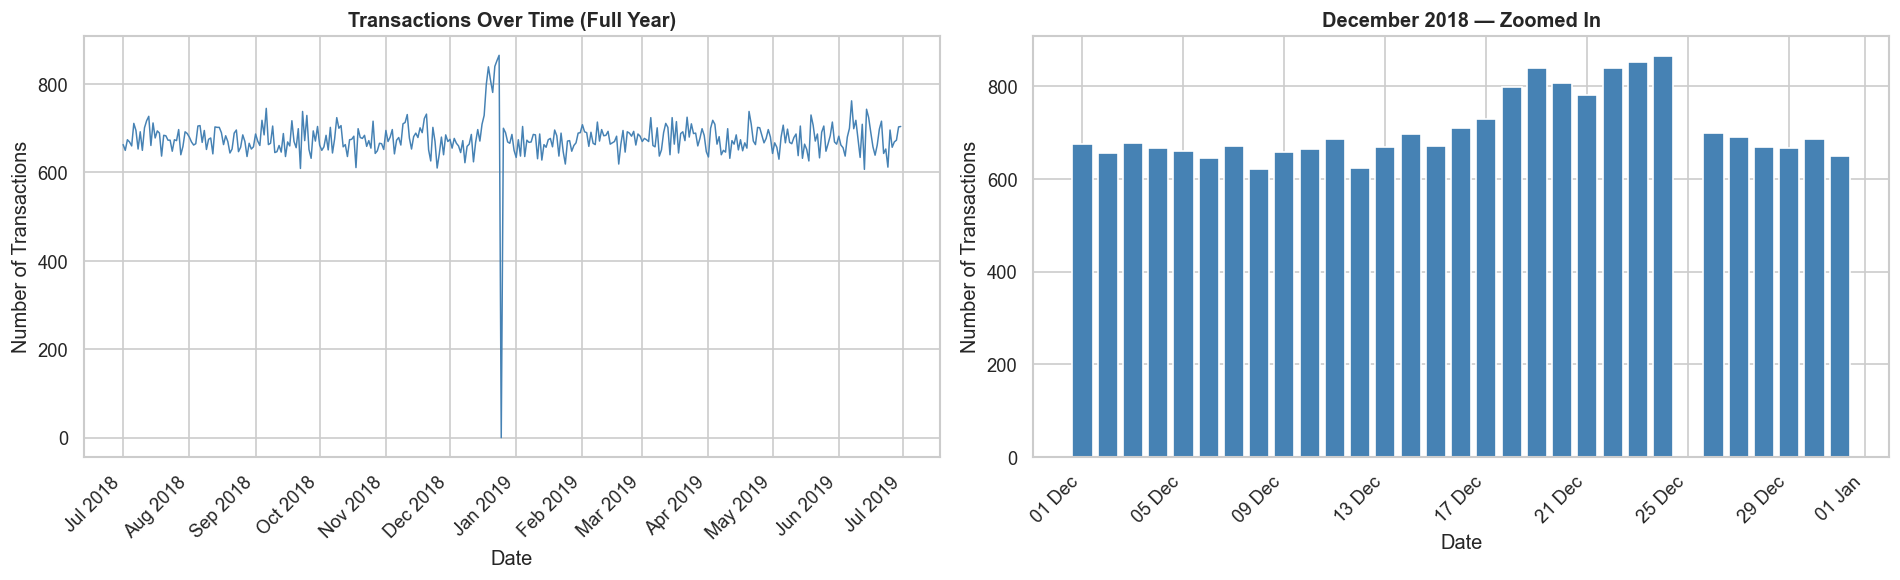


Insight: Sales spike in the lead-up to Christmas, then drop to ZERO on 25 Dec (shops closed).


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Full year
axes[0].plot(txn_by_day['DATE'], txn_by_day['TXN_COUNT'], linewidth=0.9, color='steelblue')
axes[0].set_title('Transactions Over Time (Full Year)', fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Number of Transactions')
axes[0].xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator())
axes[0].xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45, ha='right')


dec = txn_by_day[
    (txn_by_day['DATE'] >= '2018-12-01') & (txn_by_day['DATE'] <= '2018-12-31')
]
axes[1].bar(dec['DATE'], dec['TXN_COUNT'], color='steelblue', width=0.8)
axes[1].set_title('December 2018 — Zoomed In', fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Number of Transactions')
axes[1].xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%d %b'))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('fig_transactions_over_time.png', bbox_inches='tight')
plt.show()
print('\nInsight: Sales spike in the lead-up to Christmas, then drop to ZERO on 25 Dec (shops closed).')

#### FEATURE ENGINEERING

#### 2.1 PACK SIZE (Grams)

In [16]:
# Extract the numeric weight from product name (e.g. '175g' → 175)
transaction_data['PACK_SIZE'] = (
    transaction_data['PROD_NAME']
    .str.extract(r'(\d+)[Gg]', expand=False)
    .astype(float)
)

print('Pack size distribution:')
print(transaction_data['PACK_SIZE'].value_counts().sort_index())

Pack size distribution:
PACK_SIZE
70.0      1507
90.0      3008
110.0    22387
125.0     1454
134.0    25102
135.0     3257
150.0    40203
160.0     2970
165.0    15297
170.0    19983
175.0    66390
180.0     1468
190.0     2995
200.0     4473
210.0     6272
220.0     1564
250.0     3169
270.0     6285
330.0    12540
380.0     6416
Name: count, dtype: int64


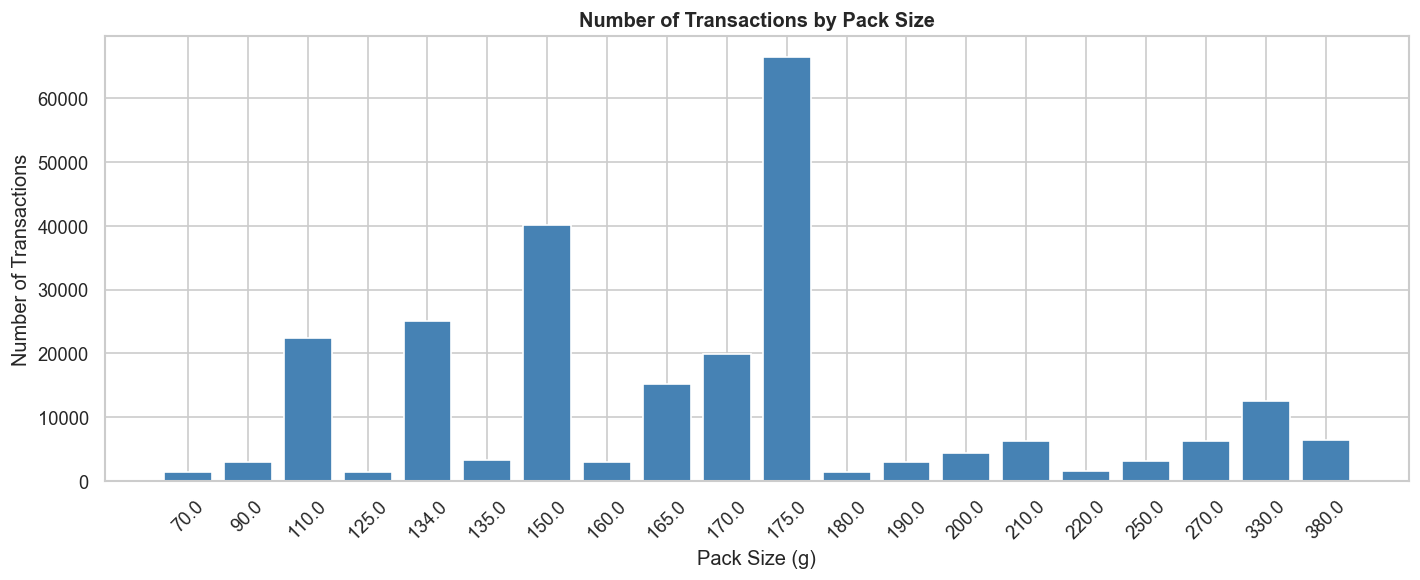

Insight: 175g is by far the most popular pack size.


In [17]:
fig, ax = plt.subplots(figsize=(12, 5))
pack_counts = transaction_data['PACK_SIZE'].value_counts().sort_index()
ax.bar(pack_counts.index.astype(str), pack_counts.values, color='steelblue', edgecolor='white')
ax.set_title('Number of Transactions by Pack Size', fontweight='bold')
ax.set_xlabel('Pack Size (g)')
ax.set_ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('fig_pack_size_distribution.png', bbox_inches='tight')
plt.show()
print('Insight: 175g is by far the most popular pack size.')

#### 2.2 Brand Name

In [18]:

transaction_data['BRAND'] = (
    transaction_data['PROD_NAME']
    .str.strip()
    .str.split()
    .str[0]
    .str.upper()
)

print('Brands found:')
print(sorted(transaction_data['BRAND'].unique()))

Brands found:
['BURGER', 'CCS', 'CHEETOS', 'CHEEZELS', 'COBS', 'DORITO', 'DORITOS', 'FRENCH', 'GRAIN', 'GRNWVES', 'INFUZIONS', 'INFZNS', 'KETTLE', 'NATURAL', 'NCC', 'PRINGLES', 'RED', 'RRD', 'SMITH', 'SMITHS', 'SNBTS', 'SUNBITES', 'THINS', 'TOSTITOS', 'TWISTIES', 'TYRRELLS', 'WOOLWORTHS', 'WW']


In [19]:

brand_map = {
    'RED'    : 'RRD',    
    'SNBTS'  : 'SUNBITES',
    'INFZNS' : 'INFUZIONS',
    'WW'     : 'WOOLWORTHS',
    'SMITH'  : 'SMITHS',
    'NCC'    : 'NATURAL',
    'DORITO' : 'DORITOS',
    'GRAIN'  : 'GRAINWAVES',
}
transaction_data['BRAND'] = transaction_data['BRAND'].replace(brand_map)

print('Cleaned brands:')
print(sorted(transaction_data['BRAND'].unique()))

Cleaned brands:
['BURGER', 'CCS', 'CHEETOS', 'CHEEZELS', 'COBS', 'DORITOS', 'FRENCH', 'GRAINWAVES', 'GRNWVES', 'INFUZIONS', 'KETTLE', 'NATURAL', 'PRINGLES', 'RRD', 'SMITHS', 'SUNBITES', 'THINS', 'TOSTITOS', 'TWISTIES', 'TYRRELLS', 'WOOLWORTHS']


#### EXAMINE CUSTOMER DATA & MERGE 

In [20]:
print('=== CUSTOMER DATA OVERVIEW ===')
print(customer_data.dtypes)
print('\nNull counts:')
print(customer_data.isnull().sum())
print('\nLIFESTAGE values:')
print(customer_data['LIFESTAGE'].value_counts())
print('\nPREMIUM_CUSTOMER values:')
print(customer_data['PREMIUM_CUSTOMER'].value_counts())

=== CUSTOMER DATA OVERVIEW ===
LYLTY_CARD_NBR       int64
LIFESTAGE           object
PREMIUM_CUSTOMER    object
dtype: object

Null counts:
LYLTY_CARD_NBR      0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

LIFESTAGE values:
LIFESTAGE
RETIREES                  14805
OLDER SINGLES/COUPLES     14609
YOUNG SINGLES/COUPLES     14441
OLDER FAMILIES             9780
YOUNG FAMILIES             9178
MIDAGE SINGLES/COUPLES     7275
NEW FAMILIES               2549
Name: count, dtype: int64

PREMIUM_CUSTOMER values:
PREMIUM_CUSTOMER
Mainstream    29245
Budget        24470
Premium       18922
Name: count, dtype: int64


In [21]:
# Merge — LEFT JOIN on LYLTY_CARD_NBR

data = transaction_data.merge(customer_data, on='LYLTY_CARD_NBR', how='left')

print(f'Transaction rows  : {len(transaction_data)}')
print(f'Merged rows       : {len(data)}')
print(f'\nNull values after merge:')
print(data[['LIFESTAGE','PREMIUM_CUSTOMER']].isnull().sum())

Transaction rows  : 246740
Merged rows       : 246740

Null values after merge:
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64


In [22]:
# Save merged dataset 
data.to_csv('QVI_data.csv', index=False)
print('Merged dataset saved as QVI_data.csv ✓')
data.head()

Merged dataset saved as QVI_data.csv ✓


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175.0,NATURAL,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175.0,CCS,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170.0,SMITHS,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,175.0,SMITHS,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,150.0,KETTLE,MIDAGE SINGLES/COUPLES,Budget


#### DATA ANALYSIS ON CUSTOMER SEGMENTS 

#### 4.1 Total segments by Segments

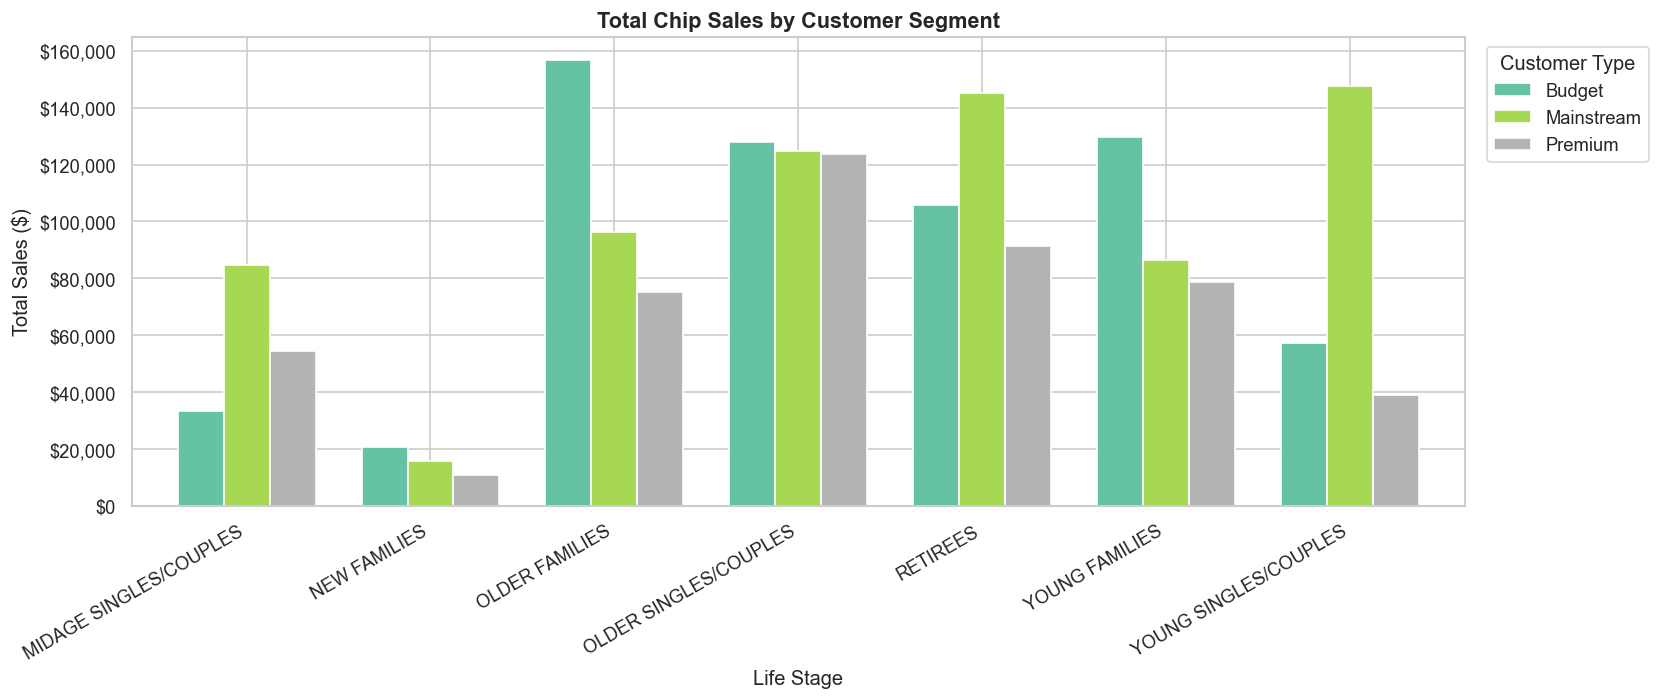


Top 5 segments by sales:
                LIFESTAGE PREMIUM_CUSTOMER  TOTAL_SALES
6          OLDER FAMILIES           Budget    156863.75
19  YOUNG SINGLES/COUPLES       Mainstream    147582.20
13               RETIREES       Mainstream    145168.95
15         YOUNG FAMILIES           Budget    129717.95
9   OLDER SINGLES/COUPLES           Budget    127833.60


In [23]:
sales_by_seg = (
    data.groupby(['LIFESTAGE','PREMIUM_CUSTOMER'])['TOT_SALES']
    .sum()
    .reset_index(name='TOTAL_SALES')
    .sort_values('TOTAL_SALES', ascending=False)
)

fig, ax = plt.subplots(figsize=(14, 6))
pivot = sales_by_seg.pivot(index='LIFESTAGE', columns='PREMIUM_CUSTOMER', values='TOTAL_SALES').fillna(0)
pivot.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='white', width=0.75)
ax.set_title('Total Chip Sales by Customer Segment', fontweight='bold', fontsize=13)
ax.set_xlabel('Life Stage')
ax.set_ylabel('Total Sales ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.xticks(rotation=30, ha='right')
plt.legend(title='Customer Type', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('fig_total_sales_by_segment.png', bbox_inches='tight')
plt.show()

print('\nTop 5 segments by sales:')
print(sales_by_seg.head())

#### 4.2 Number of Unique Customer Per Segments

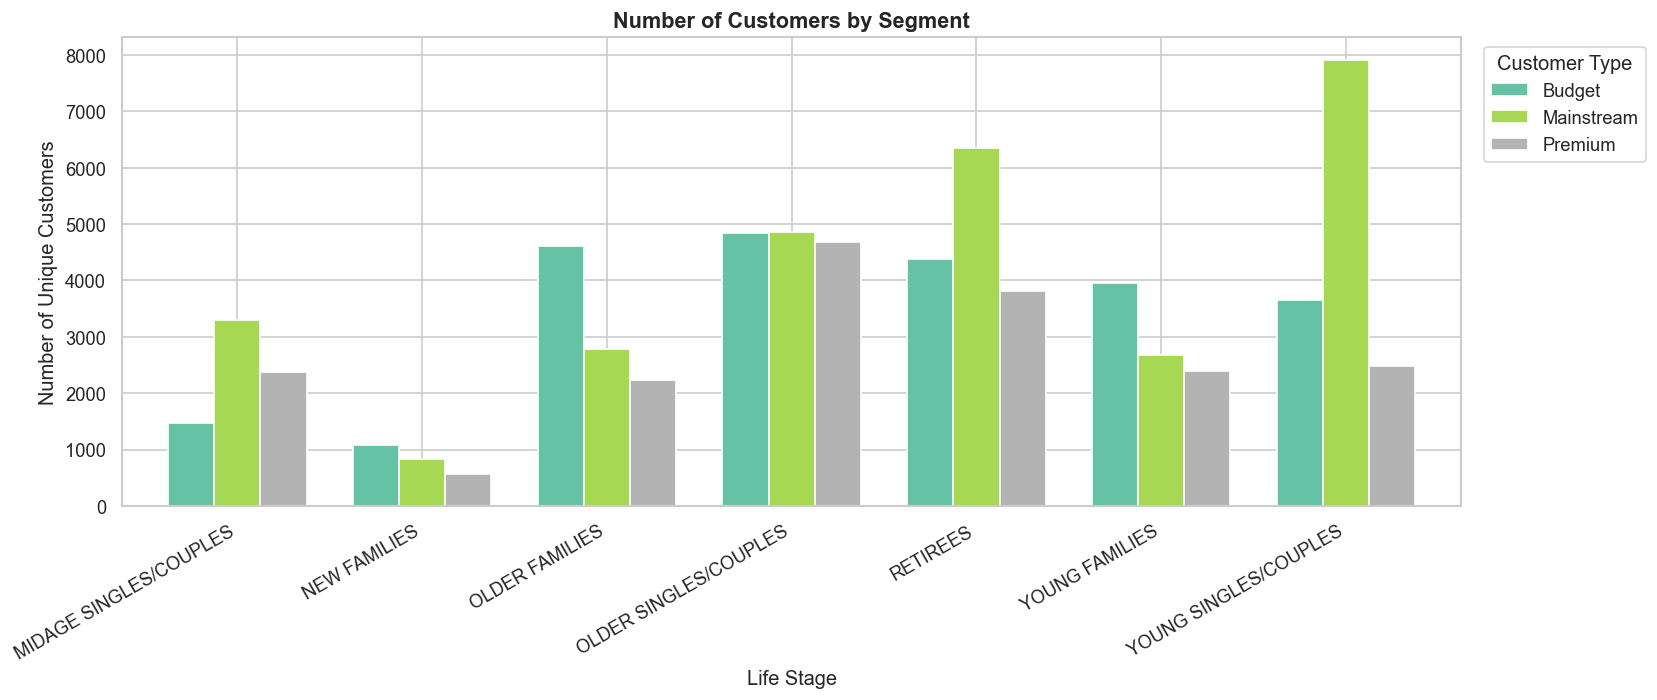

In [24]:
customers_by_seg = (
    data.groupby(['LIFESTAGE','PREMIUM_CUSTOMER'])['LYLTY_CARD_NBR']
    .nunique()
    .reset_index(name='NUM_CUSTOMERS')
    .sort_values('NUM_CUSTOMERS', ascending=False)
)

fig, ax = plt.subplots(figsize=(14, 6))
pivot2 = customers_by_seg.pivot(index='LIFESTAGE', columns='PREMIUM_CUSTOMER', values='NUM_CUSTOMERS').fillna(0)
pivot2.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='white', width=0.75)
ax.set_title('Number of Customers by Segment', fontweight='bold', fontsize=13)
ax.set_xlabel('Life Stage')
ax.set_ylabel('Number of Unique Customers')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Customer Type', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('fig_customers_by_segment.png', bbox_inches='tight')
plt.show()